In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
np.random.seed(42)
n_rows = 1000

data = {
    'Transaction_ID': np.arange(1000, 1000 + n_rows),
    'Date': pd.date_range(start='2025-01-01', periods=n_rows, freq='D'),
    'Customer_Age': np.random.randint(18, 70, size=n_rows),
    'Gender': np.random.choice(['Male', 'Female'], size=n_rows, p=[0.48, 0.52]),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Beauty'], size=n_rows),
    'Product_ID': np.random.choice([f'PROD_{i}' for i in range(1, 21)], size=n_rows),
    'Quantity': np.random.randint(1, 6, size=n_rows),
    'Price_Per_Unit': np.random.uniform(10, 500, size=n_rows).round(2)
}

df_retail = pd.DataFrame(data)
df_retail['Total_Sales'] = df_retail['Quantity'] * df_retail['Price_Per_Unit']

# Inject missing values for demonstration
df_retail.loc[df_retail.sample(frac=0.02).index, 'Customer_Age'] = np.nan

print(f"Dataset Shape: {df_retail.shape}")
print("\n--- Column Data Types & Info ---")
print(df_retail.info())

print("\n--- Missing Value Check ---")
print(df_retail.isnull().sum())

# Modern Pandas reassignment (Fixes ChainedAssignmentError)
df_retail['Customer_Age'] = df_retail['Customer_Age'].fillna(df_retail['Customer_Age'].median())

Dataset Shape: (1000, 9)

--- Column Data Types & Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer_Age      980 non-null    float64       
 3   Gender            1000 non-null   str           
 4   Product_Category  1000 non-null   str           
 5   Product_ID        1000 non-null   str           
 6   Quantity          1000 non-null   int32         
 7   Price_Per_Unit    1000 non-null   float64       
 8   Total_Sales       1000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int32(1), int64(1), str(3)
memory usage: 86.3 KB
None

--- Missing Value Check ---
Transaction_ID       0
Date                 0
Customer_Age        20
Gender               0
Product_Category     0
Product_ID      

In [4]:
num_cols = ['Customer_Age', 'Quantity', 'Price_Per_Unit', 'Total_Sales']
desc_stats = df_retail[num_cols].describe().T
desc_stats['mode'] = df_retail[num_cols].mode().iloc[0]

print("\n--- Numerical Descriptive Statistics ---")
print(desc_stats[['mean', '50%', 'mode', 'std', 'min', 'max']].rename(columns={'50%': 'median'}))


--- Numerical Descriptive Statistics ---
                     mean   median    mode         std    min      max
Customer_Age     43.80500   44.000   44.00   14.847337  18.00    69.00
Quantity          3.06700    3.000    5.00    1.403738   1.00     5.00
Price_Per_Unit  252.33436  252.985   36.35  141.565493  10.09   498.49
Total_Sales     771.09537  627.160  205.16  590.340627  17.02  2487.00


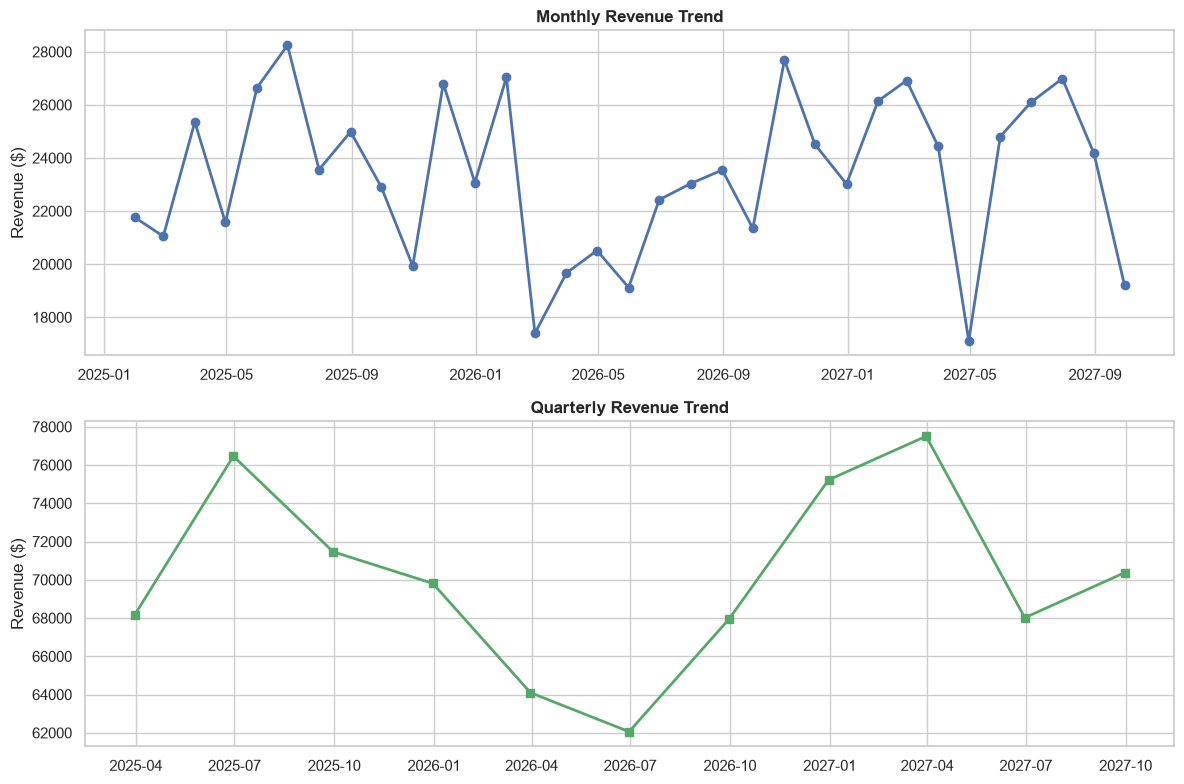

In [5]:
df_time = df_retail.set_index('Date')
monthly_sales = df_time['Total_Sales'].resample('ME').sum()
quarterly_sales = df_time['Total_Sales'].resample('QE').sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linewidth=2)
axes[0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')

axes[1].plot(quarterly_sales.index, quarterly_sales.values, marker='s', color='g', linewidth=2)
axes[1].set_title('Quarterly Revenue Trend', fontweight='bold')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

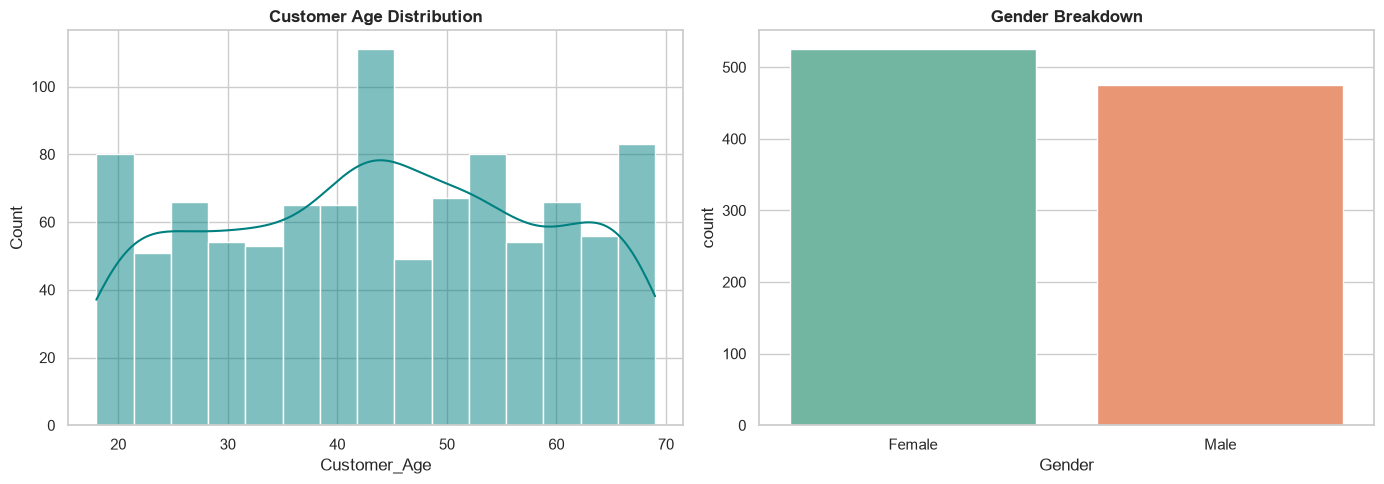

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution
sns.histplot(df_retail['Customer_Age'], kde=True, bins=15, ax=axes[0], color='teal')
axes[0].set_title('Customer Age Distribution', fontweight='bold')

# Gender Breakdown (Fixed Seaborn palette deprecation warning)
sns.countplot(data=df_retail, x='Gender', hue='Gender', palette='Set2', ax=axes[1])
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
axes[1].set_title('Gender Breakdown', fontweight='bold')

plt.tight_layout()
plt.show()

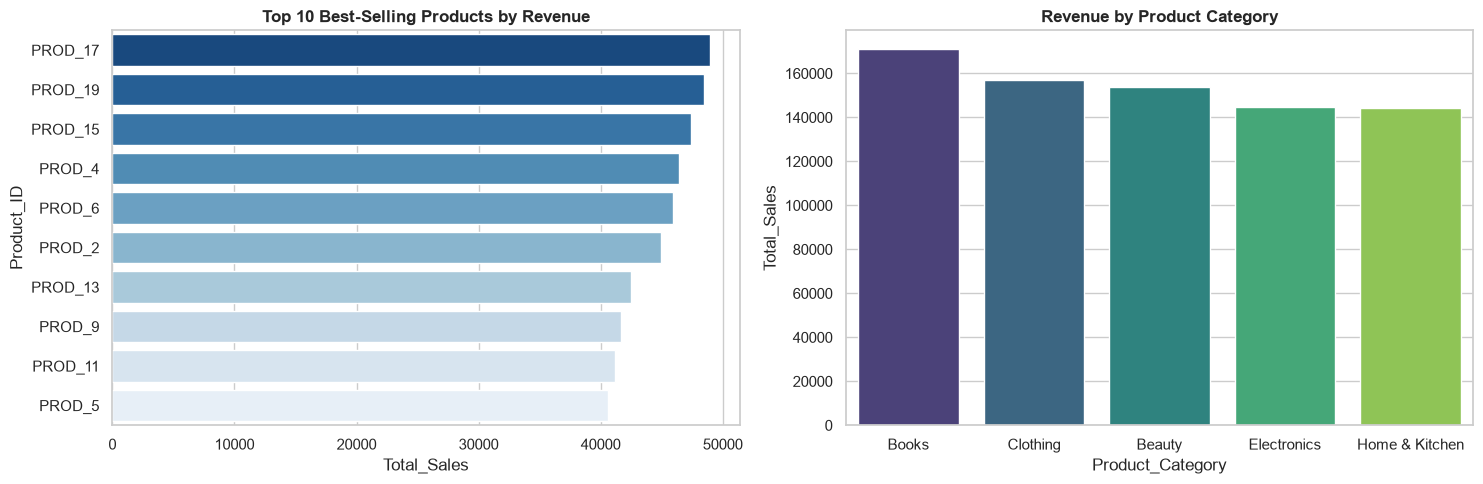

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 Best-Selling Products by Revenue
top_products = df_retail.groupby('Product_ID')['Total_Sales'].sum().nlargest(10).reset_index()
sns.barplot(
    data=top_products, 
    x='Total_Sales', 
    y='Product_ID', 
    hue='Product_ID', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Top 10 Best-Selling Products by Revenue', fontweight='bold')

# Revenue by Product Category
cat_revenue = df_retail.groupby('Product_Category')['Total_Sales'].sum().reset_index().sort_values('Total_Sales', ascending=False)
sns.barplot(
    data=cat_revenue, 
    x='Product_Category', 
    y='Total_Sales', 
    hue='Product_Category', 
    palette='viridis', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Revenue by Product Category', fontweight='bold')

plt.tight_layout()
plt.show()

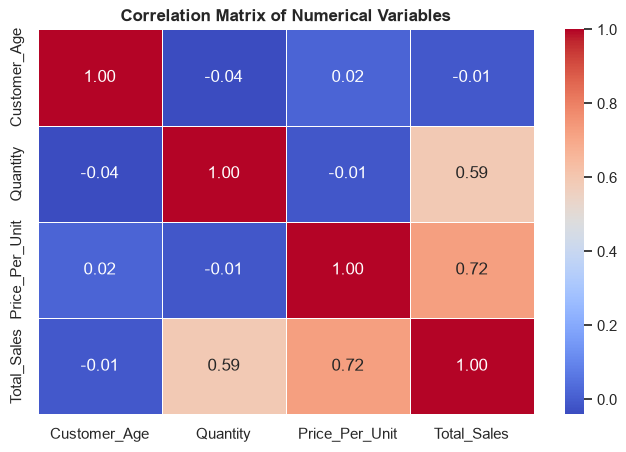

In [10]:
plt.figure(figsize=(8, 5))
sns.heatmap(df_retail[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontweight='bold')
plt.show()

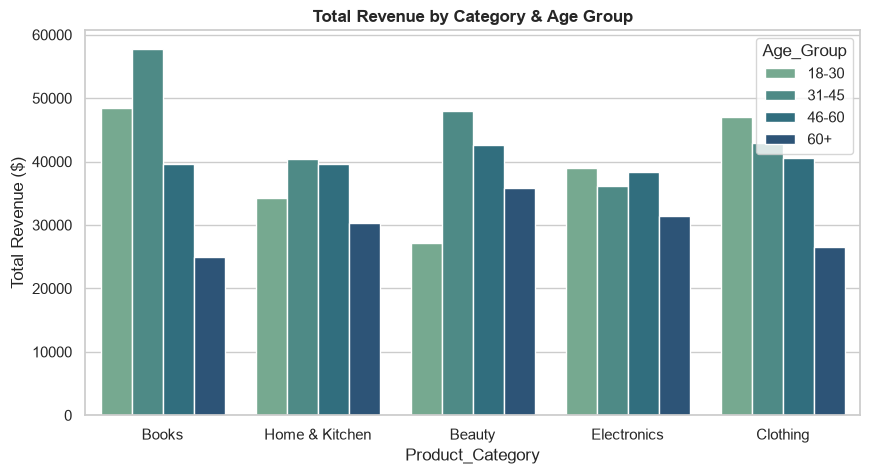

In [11]:
df_retail['Age_Group'] = pd.cut(df_retail['Customer_Age'], bins=[17, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])

plt.figure(figsize=(10, 5))
sns.barplot(data=df_retail, x='Product_Category', y='Total_Sales', hue='Age_Group', estimator=sum, errorbar=None, palette='crest')
plt.title('Total Revenue by Category & Age Group', fontweight='bold')
plt.ylabel('Total Revenue ($)')
plt.show()